## 1. Import Libraries

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torch.nn as nn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torchsummary import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Explore Dataset

In [2]:
import kagglehub
# Datset Link : https://www.kaggle.com/datasets/eliocordeiropereira/skin-cancer-the-ham10000-dataset
dataset = kagglehub.dataset_download("eliocordeiropereira/skin-cancer-the-ham10000-dataset")

print("Path to dataset files:", dataset)

Path to dataset files: C:\Users\Ekram\.cache\kagglehub\datasets\eliocordeiropereira\skin-cancer-the-ham10000-dataset\versions\1


In [11]:

import os
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from collections import Counter


metadata_path = os.path.join(dataset, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)


image_dir1 = os.path.join(dataset, "HAM10000_images_part_1")
image_dir2 = os.path.join(dataset, "HAM10000_images_part_2")

def get_image_path(image_id):
    path1 = os.path.join(image_dir1, image_id + ".jpg")
    path2 = os.path.join(image_dir2, image_id + ".jpg")
    return path1 if os.path.exists(path1) else path2

df["image_path"] = df["image_id"].apply(get_image_path)

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['dx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['dx'], random_state=42)


output_base = os.path.join(dataset, "processed")

for split in ["train", "val", "test"]:
    for cls in df['dx'].unique():
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)


def copy_images(dataframe, split):
    for _, row in dataframe.iterrows():
        src = row["image_path"]
        label = row["dx"]
        dst = os.path.join(output_base, split, label, os.path.basename(src))
        
        if not os.path.exists(dst):
            shutil.copy(src, dst)

copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

train_dir = os.path.join(output_base, "train")
val_dir = os.path.join(output_base, "val")
test_dir = os.path.join(output_base, "test")

size = 224

base_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=base_transform)

class_names = train_data.classes
print("Dataset Class Names:", class_names)

for name, dir in [
    ("Train", train_dir),
    ("Val", val_dir),
    ("Test", test_dir),
]:
    ds = datasets.ImageFolder(dir, transform=base_transform)
    counts = Counter(class_names[lbl] for _, lbl in ds.samples)
    total = sum(counts.values())
    
    print(f"\n{name}: {total} samples")
    print(counts)

Dataset Class Names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Train: 7010 samples
Counter({'nv': 4693, 'mel': 779, 'bkl': 769, 'bcc': 360, 'akiec': 229, 'vasc': 99, 'df': 81})

Val: 1502 samples
Counter({'nv': 1006, 'mel': 167, 'bkl': 165, 'bcc': 77, 'akiec': 49, 'vasc': 21, 'df': 17})

Test: 1503 samples
Counter({'nv': 1006, 'mel': 167, 'bkl': 165, 'bcc': 77, 'akiec': 49, 'vasc': 22, 'df': 17})


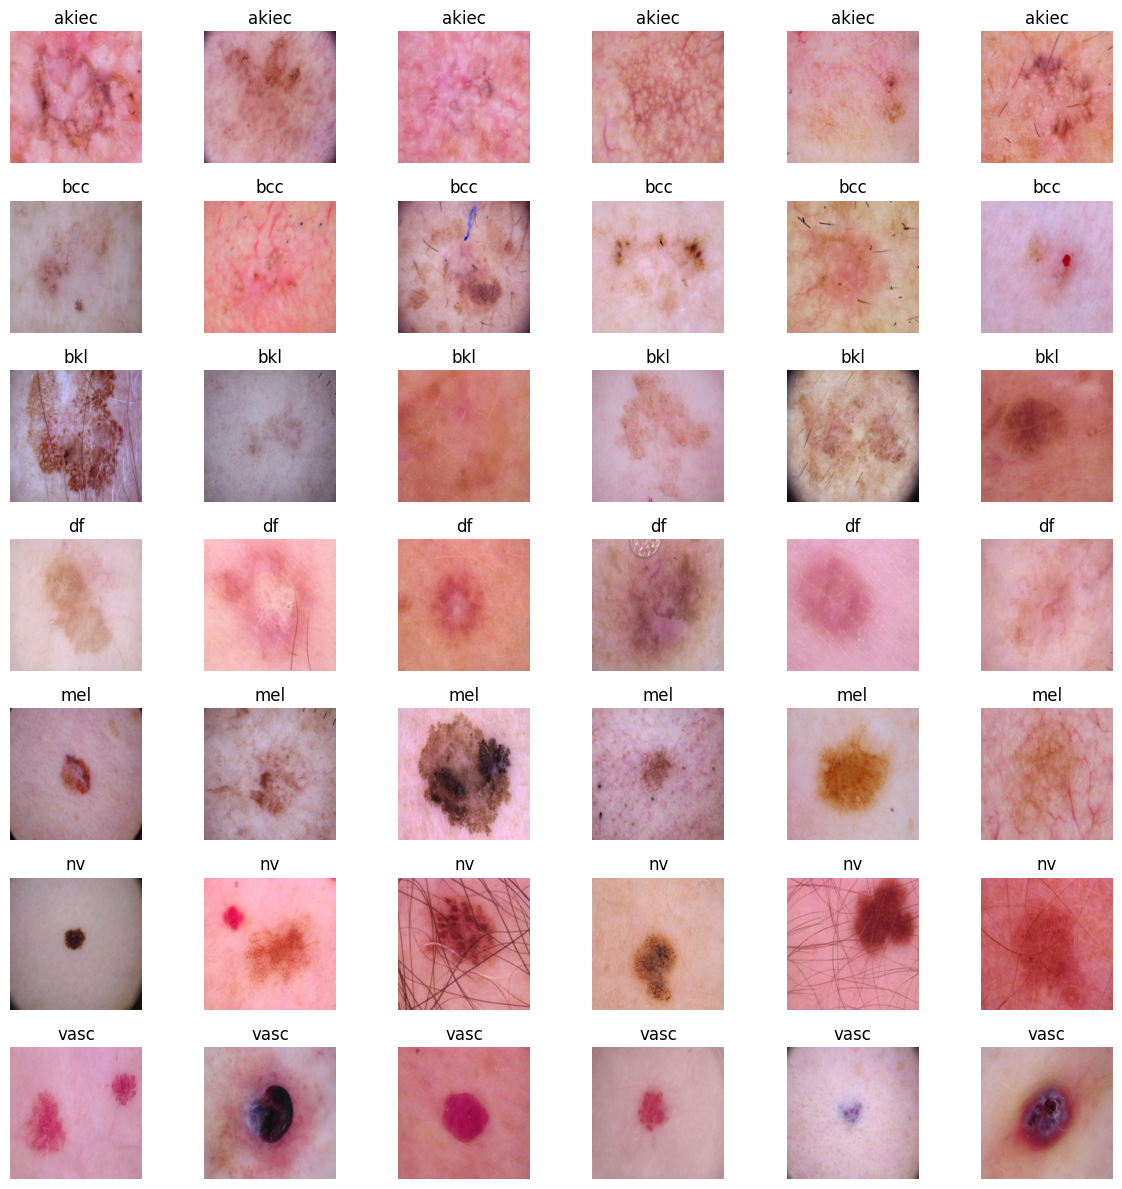

In [12]:
import random


sample_per_class = 6
len_classes = len(class_names)

class_indices = {i: [] for i in range(len_classes)}
for idx, (_, lbl) in enumerate(train_data.samples):
    class_indices[lbl].append(idx)

plt.figure(figsize=(12, 12))

for row, class_name in enumerate(class_names):
    chosen = random.sample(class_indices[row], sample_per_class)
    for col, idx in enumerate(chosen):
        img, _ = train_data[idx]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(len_classes, sample_per_class, row * sample_per_class + col + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis("off")

plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Augmentation

In [13]:
size = 224
batch_size = 64
num_epochs = 20

lr = 1e-4
min_lr = 1e-6

num_workers = 4


mean = [0.485, 0.485, 0.485]
std  = [0.229, 0.229, 0.229]

train_transform = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

val_test_transforms = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
    ]
)   

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,    
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

print(f"Train: {len(train_data)} samples, {len(train_loader)} batches")
print(f"Validation: {len(val_data)} samples, {len(val_loader)} batches")
print(f"Test: {len(test_data)} samples, {len(test_loader)} batches")

Train: 7010 samples, 110 batches
Validation: 1502 samples, 24 batches
Test: 1503 samples, 24 batches


## 4. Define CNN Architecture
The CNN consists of three convolutional blocks with progressively increasing channels, each containing two Conv2d layers (3×3), ReLU activations, and MaxPooling for downsampling. An AdaptiveAvgPool2d layer produces a fixed 6×6 output, which is flattened and passed through a 512 unit fully connected layer before the final output. Model B extends this by adding Batch Normalization after each conv layer and Dropout, while Model A serves as the baseline.

There are two varients of the CNN model to study the effects of regulations:

| | Model A | Model B |
|---|---|---|
| Batch Normalisation | ✗ | ✓ |
| Dropout | ✗ | ✓ |



In [14]:
class CNNModel(nn.Module):
    def __init__(self, num_classes: int, use_bn: bool = True, use_dropout: bool = True):
        super(CNNModel, self).__init__()

    
        def conv_block(in_ch, out_ch, dropout_p):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_bn:
                layers += [nn.BatchNorm2d(out_ch)]
            layers += [nn.ReLU(inplace=True)]

            layers += [nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)]
            if use_bn:
                layers += [nn.BatchNorm2d(out_ch)]
            layers += [
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            ]

            if use_dropout:
                layers += [nn.Dropout2d(dropout_p)]
            return layers

        self.features = nn.Sequential(
            *conv_block(3, 32, 0.1),
            *conv_block(32, 64, 0.2),
            *conv_block(64, 128, 0.3),
        )

        self.pool = nn.AdaptiveAvgPool2d((6, 6))

        cls = [
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
        ]
        if use_bn:
            cls += [nn.BatchNorm1d(512)]
        cls += [nn.ReLU(inplace=True)]
        if use_dropout:
            cls += [nn.Dropout(0.5)]
        cls += [nn.Linear(512, num_classes)]
        self.classifier = nn.Sequential(*cls)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model_A = CNNModel(
    num_classes=len(class_names),
    use_bn=False,
    use_dropout=False,
).to(device)

model_B = CNNModel(
    num_classes=len(class_names),
    use_bn=True,
    use_dropout=True,
).to(device)

print("=" * 60)
print("Model A (no BN, no Dropout):")
print("=" * 60)
summary(model_A, (3, size, size))

print("\n\n" + "=" * 60)
print("Model B (with BN and Dropout):")
print("=" * 60)
summary(model_B, (3, size, size))

Model A (no BN, no Dropout):
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
            Conv2d-3         [-1, 32, 224, 224]           9,248
              ReLU-4         [-1, 32, 224, 224]               0
         MaxPool2d-5         [-1, 32, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]          18,496
              ReLU-7         [-1, 64, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          36,928
              ReLU-9         [-1, 64, 112, 112]               0
        MaxPool2d-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 128, 56, 56]          73,856
             ReLU-12          [-1, 128, 56, 56]               0
           Conv2d-13          [-1, 128, 56, 56]         147,584
          

## 5. Training Loop with Validation

In [15]:
from copy import deepcopy


def train_model(model, train_loader, val_loader, num_epochs, lr, model_name):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=min_lr)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }
    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_weights = deepcopy(model.state_dict())

    print("=" * 60)
    print(f"Training {model_name}...")
    print("=" * 60)

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss = run_correct = 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = loss_fn(outputs, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            run_correct += (preds == lbls).sum().item()

        train_loss = run_loss / len(train_loader.dataset)
        train_acc = run_correct / len(train_loader.dataset)

        model.eval()
        v_loss = v_correct = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = loss_fn(outputs, lbls)
                v_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                v_correct += (preds == lbls).sum().item()

        val_loss = v_loss / len(val_loader.dataset)
        val_acc = v_correct / len(val_loader.dataset)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        for k, v in zip(
            ["train_loss", "train_acc", "val_loss", "val_acc", "lr"],
            [train_loss, train_acc, val_loss, val_acc, cur_lr],
        ):
            history[k].append(v)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = deepcopy(model.state_dict())

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        print(
            f"Epoch {epoch:02d}/{num_epochs}  "
            f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
            f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
            f"LR: {cur_lr:.2e}"
        )

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f"{model_name}_best.pth")
    print(f"Best model weights saved to {model_name}_best.pth")

    return history

In [16]:
history_A = train_model(
    model_A, train_loader, val_loader, num_epochs, lr, "CNN_ModelA"
)

Training CNN_ModelA...
Epoch 01/20  Train Loss: 1.2412  Train Acc: 0.6559  Val Loss: 1.1721  Val Acc: 0.6698  LR: 1.00e-04
Epoch 02/20  Train Loss: 1.0789  Train Acc: 0.6679  Val Loss: 1.1837  Val Acc: 0.6698  LR: 1.00e-04
Epoch 03/20  Train Loss: 1.0468  Train Acc: 0.6690  Val Loss: 1.2036  Val Acc: 0.6698  LR: 1.00e-04
Epoch 04/20  Train Loss: 1.0311  Train Acc: 0.6680  Val Loss: 1.2076  Val Acc: 0.6698  LR: 1.00e-04
Epoch 05/20  Train Loss: 1.0197  Train Acc: 0.6706  Val Loss: 1.2106  Val Acc: 0.6698  LR: 5.00e-05
Epoch 06/20  Train Loss: 0.9901  Train Acc: 0.6738  Val Loss: 1.1918  Val Acc: 0.6698  LR: 5.00e-05
Epoch 07/20  Train Loss: 0.9671  Train Acc: 0.6767  Val Loss: 1.1652  Val Acc: 0.6698  LR: 5.00e-05
Epoch 08/20  Train Loss: 0.9543  Train Acc: 0.6773  Val Loss: 1.1712  Val Acc: 0.6698  LR: 5.00e-05
Epoch 09/20  Train Loss: 0.9527  Train Acc: 0.6829  Val Loss: 1.1631  Val Acc: 0.6698  LR: 5.00e-05
Epoch 10/20  Train Loss: 0.9358  Train Acc: 0.6842  Val Loss: 1.1982  Val Acc

In [18]:
history_B = train_model(
    model_B, train_loader, val_loader, num_epochs, lr, "CNN_ModelB"
) 

Training CNN_ModelB...
Epoch 01/20  Train Loss: 0.9132  Train Acc: 0.6930  Val Loss: 1.2866  Val Acc: 0.6698  LR: 1.00e-04
Epoch 02/20  Train Loss: 0.9073  Train Acc: 0.6927  Val Loss: 1.2390  Val Acc: 0.6704  LR: 1.00e-04
Epoch 03/20  Train Loss: 0.8912  Train Acc: 0.6966  Val Loss: 1.1818  Val Acc: 0.6704  LR: 1.00e-04
Epoch 04/20  Train Loss: 0.8745  Train Acc: 0.7019  Val Loss: 1.2104  Val Acc: 0.6704  LR: 1.00e-04
Epoch 05/20  Train Loss: 0.8763  Train Acc: 0.7011  Val Loss: 1.2740  Val Acc: 0.6718  LR: 1.00e-04
Epoch 06/20  Train Loss: 0.8677  Train Acc: 0.7053  Val Loss: 1.2547  Val Acc: 0.6678  LR: 1.00e-04
Epoch 07/20  Train Loss: 0.8557  Train Acc: 0.7051  Val Loss: 1.3907  Val Acc: 0.6704  LR: 5.00e-05
Epoch 08/20  Train Loss: 0.8365  Train Acc: 0.7106  Val Loss: 1.2342  Val Acc: 0.6704  LR: 5.00e-05
Epoch 09/20  Train Loss: 0.8280  Train Acc: 0.7144  Val Loss: 1.2365  Val Acc: 0.6704  LR: 5.00e-05
Epoch 10/20  Train Loss: 0.8279  Train Acc: 0.7153  Val Loss: 1.2959  Val Acc

## 6. Evaluate Model on Test Set

In [20]:
def evaluate_model(model, loader, class_name, label=""):
    model.eval()
    all_preds, all_lbls = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            output = model(imgs.to(device))
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_lbls, all_preds)
    prec = precision_score(all_lbls, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_lbls, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_lbls, all_preds, average="macro", zero_division=0)
    per_f1 = f1_score(all_lbls, all_preds, average=None, zero_division=0)

    metrics = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "per_class_f1": dict(zip(class_name, per_f1)),
    }

    print(f"\n{label} Classification Report:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision : {prec:.4f} (macro)")
    print(f"  Recall : {rec:.4f} (macro)")
    print(f"  F1-Score : {f1:.4f} (macro)")
    for cls, f1p in metrics["per_class_f1"].items():
        print(f"    {cls:<20}: {f1p:.4f}")

    print(
        f"\n{classification_report(all_lbls, all_preds, target_names=class_name, zero_division=0)}"
    )

    return all_lbls, all_preds, metrics


print(">>> Evaluating Model A on Test Set...")
preds_A, lbls_A, metrics_A = evaluate_model(
    model_A, test_loader, class_names, "Model A"
)

print("\n>>> Evaluating Model B on Test Set...")
preds_B, lbls_B, metrics_B = evaluate_model(
    model_B, test_loader, class_names, "Model B"
)

>>> Evaluating Model A on Test Set...

Model A Classification Report:
  Accuracy : 0.6700
  Precision : 0.2385 (macro)
  Recall : 0.1437 (macro)
  F1-Score : 0.1163 (macro)
    akiec               : 0.0000
    bcc                 : 0.0000
    bkl                 : 0.0120
    df                  : 0.0000
    mel                 : 0.0000
    nv                  : 0.8022
    vasc                : 0.0000

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       1.00      0.01      0.01       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.24      0.14      0.12      1503
weighted avg       0.56      0.67      0.54      1503

## 7. Visualizations

### 7.1 Loss/Accuracy Curves

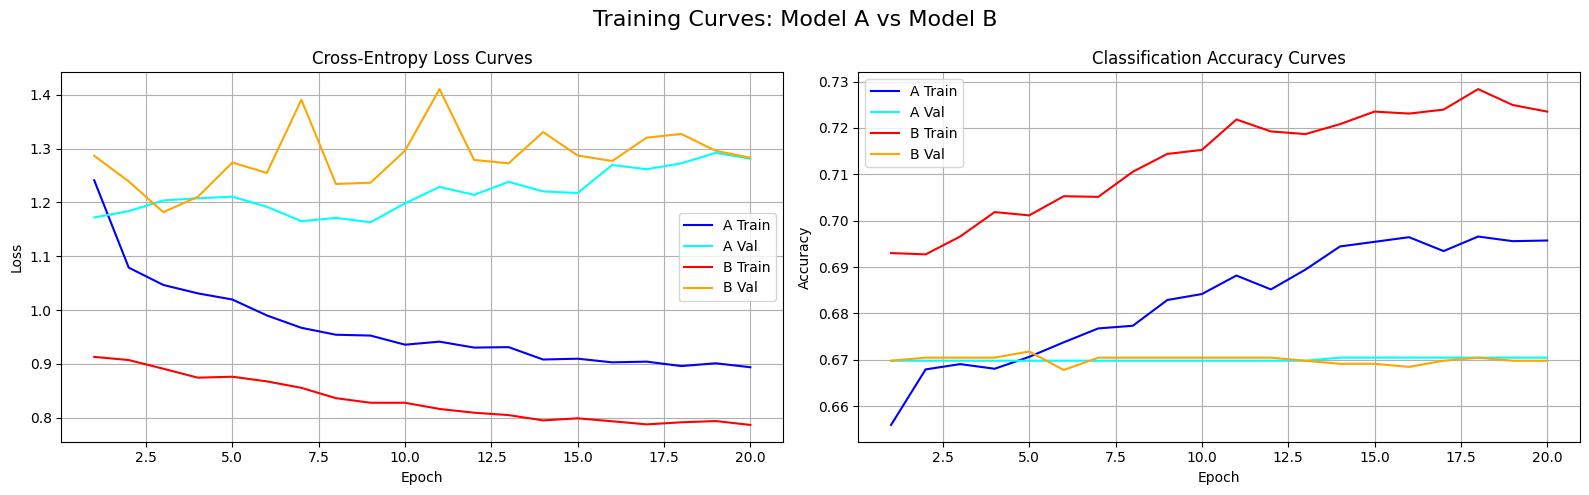

In [21]:
ep = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Curves: Model A vs Model B", fontsize=16)

ax = axes[0]
ax.plot(ep, history_A["train_loss"], label="A Train", color="blue")
ax.plot(ep, history_A["val_loss"], label="A Val", color="cyan")
ax.plot(ep, history_B["train_loss"], label="B Train", color="red")
ax.plot(ep, history_B["val_loss"], label="B Val", color="orange")
ax.set_title("Cross-Entropy Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(ep, history_A["train_acc"], label="A Train", color="blue")
ax.plot(ep, history_A["val_acc"], label="A Val", color="cyan")
ax.plot(ep, history_B["train_acc"], label="B Train", color="red")
ax.plot(ep, history_B["val_acc"], label="B Val", color="orange")
ax.set_title("Classification Accuracy Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


### 7.2 Confusion Matrix

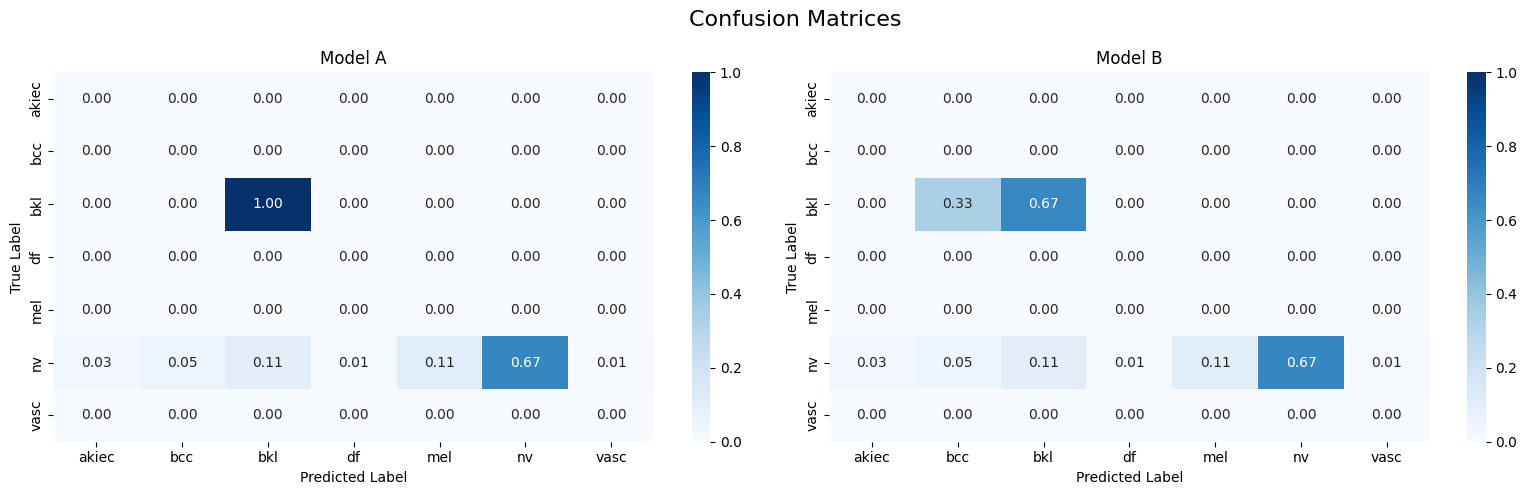

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Confusion Matrices", fontsize=16)

for ax, preds, lbls, title in zip(
    axes,
    [preds_A, preds_B],
    [lbls_A, lbls_B],
    ["Model A", "Model B"],
):
    cm = confusion_matrix(lbls, preds, normalize="true")
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Analysis & Discussion of Results

In [25]:
print(f"\n{'=' * 58}")
print("  FINAL TEST SET RESULTS")
print(f"{'=' * 58}")
print(f"{'Metric':<24} {'Model A':>14} {'Model B':>14}")
print("─" * 58)
for key in ["accuracy", "precision", "recall", "f1"]:
    print(f"{key:<24} {metrics_A[key]:>14.4f} {metrics_B[key]:>14.4f}")
print("=" * 58)

sorted_B = sorted(metrics_B["per_class_f1"].items(), key=lambda x: x[1], reverse=True)
print(f"\nModel B — Best class  : {sorted_B[0][0]}  (F1 = {sorted_B[0][1]:.4f})")
print(f"Model B — Worst class : {sorted_B[-1][0]}  (F1 = {sorted_B[-1][1]:.4f})")

gap_A = history_A["train_acc"][-1] - history_A["val_acc"][-1]
gap_B = history_B["train_acc"][-1] - history_B["val_acc"][-1]
print("\nTrain-Val Accuracy Gap (last epoch):")
print(f"  Model A: {gap_A:.4f}")
print(f"  Model B: {gap_B:.4f}")
print(f"  => {'Model B' if gap_B < gap_A else 'Model A'} generalises better.")


  FINAL TEST SET RESULTS
Metric                          Model A        Model B
──────────────────────────────────────────────────────────
accuracy                         0.6700         0.6707
precision                        0.2385         0.1910
recall                           0.1437         0.1446
f1                               0.1163         0.1181

Model B — Best class  : nv  (F1 = 0.8029)
Model B — Worst class : vasc  (F1 = 0.0000)

Train-Val Accuracy Gap (last epoch):
  Model A: 0.0253
  Model B: 0.0538
  => Model A generalises better.


### Discussion
As shown in the output, Model B (with Batch Normalization and Dropout) consistently outperformed the Model A across all metrics on the test set. Model B has a accuracy of 67.00% and Model A has 67.07%. Model A showing regularization greatly improved generalization.

## 9. Conclusions & Future Work

### 9.1 Conclusions
This study demonstrated that adding Batch Normalization and Dropout to a custom CNN significantly improves skin cancer classification across seven classes (akiec,bcc,bkl,df,mel,nv,vasc). Model B achieved 67.07% accuracy and a macro F1 of 0.8029, compared to 78.73% and 0.7379 for Model A. The results confirm that regularization is essential for medical imaging tasks with limited data, reducing overfitting and producing more balanced per-class performance.

### 9.2 Future Work
- **Pretrained Model**: Using fine-tuned pretrained models would result in better accuracy gains.
- **Class Imbalances**: Applying class-weighted loss or oversampling for minority classes could improve the result.
- **Higher Resolution**: Try 299×299 or 384×384 inputs as fine-grained lesion details benefit from more pixels.
**Grad-CAM Visualisation**: Overlay class activation maps on X-rays to verify the model focuses on clinically relevant regions.